In [1]:
from tempfile import TemporaryDirectory
import os
import torch
from torch import nn, optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchvision import datasets, models
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np

## Preprocessing ##
# Stop naming this transforms, it overwrites the module...
data_transforms = {
    'train': v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.RandomCrop(32, padding=4),
        v2.RandomHorizontalFlip(),
        # EfficientNet expects 224x224 inputs
        v2.Resize(224),
        # Use ImageNet's mean and std for normalization, not CIFAR10's
        v2.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))]),
    'val': v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Resize(224),
        v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

trainset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=data_transforms['train']
)
testset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=data_transforms['val']
)

BATCH_SIZE = 32
dataloaders = {
    'train': DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True),
    'val': DataLoader(testset, batch_size=BATCH_SIZE)
}
dataset_sizes = {
    'train': len(trainset),
    'val': len(testset)
}
class_names = trainset.classes


## Train/Eval Function ##
def train_model(model, criterion, optimizer, scheduler=None, num_epochs=25):
    # Temporary dir to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_params_path = os.path.join(tempdir, 'best_params.pt')
        torch.save(model.state_dict(), best_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 25)

            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                else:
                    model.eval()

                # Accumulators reset per epoch[phase]
                running_loss = 0.0
                running_corrects = 0

                for inputs, labels in dataloaders[phase]:
                    inputs, labels = inputs.to(device), labels.to(device)

                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        if phase == 'train':
                            optimizer.zero_grad()
                            loss.backward()
                            optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

                # Scheduler for learning rate decay
                if phase == 'train' and scheduler is not None:
                    scheduler.step()

                # Averages per epoch[phase]
                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # Save model if validation accuracy improves
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_params_path)

            print()
        print(f'Best val Acc: {best_acc:4f}')

        # Load best model
        model.load_state_dict(torch.load(best_params_path, weights_only=True))
    return model


# Display image from tensor
def imshow(ax, inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    ax.imshow(inp)
    if title is not None:
        ax.set_title(title)

# Display model predictions
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    # Subplots for displaying images
    _, axes = plt.subplots(num_images//2, 2, figsize=(8, num_images*2))
    axes = axes.flatten() # flatten for easier indexing

    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                if images_so_far >= num_images:
                    break
                ax = axes[images_so_far] # set current axis
                ax.axis('off')
                imshow(ax, inputs.cpu().data[j],
                        title=f'pred: {class_names[preds[j]]}')
                images_so_far += 1

                if images_so_far >= num_images:
                    break
    plt.tight_layout()
    plt.show()
    model.train(mode=was_training)

100%|██████████| 170M/170M [00:05<00:00, 29.5MB/s] 


In [ ]:
# Exploratory transfer learning with EfficientNet-B0 on CIFAR-10
# - Start with fixed feature extractor, only train classifier head
#    - <= 5 epochs to establish baseline (don't overfit)
# - Unfreeze all layers and apply fine-tuning w/ small learning rate
#    - Use smaller learning rate than baseline (1e-4 to 1e-3)
#    - Train across all epochs, but use scheduler to reduce LR
#    - Must reset optimizer after unfreezing to clear momentum

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 174MB/s]


Epoch 0/4
-------------------------
train Loss: 0.9726 Acc: 0.6835
val Loss: 0.6774 Acc: 0.7700

Epoch 1/4
-------------------------
train Loss: 0.8061 Acc: 0.7235
val Loss: 0.6272 Acc: 0.7869

Epoch 2/4
-------------------------
train Loss: 0.7974 Acc: 0.7250
val Loss: 0.6193 Acc: 0.7849

Epoch 3/4
-------------------------
train Loss: 0.7929 Acc: 0.7278
val Loss: 0.5894 Acc: 0.7988

Epoch 4/4
-------------------------
train Loss: 0.7848 Acc: 0.7314
val Loss: 0.5905 Acc: 0.7991

Best val Acc: 0.799100
Saved model to efficientnet_b0_ffe.pth


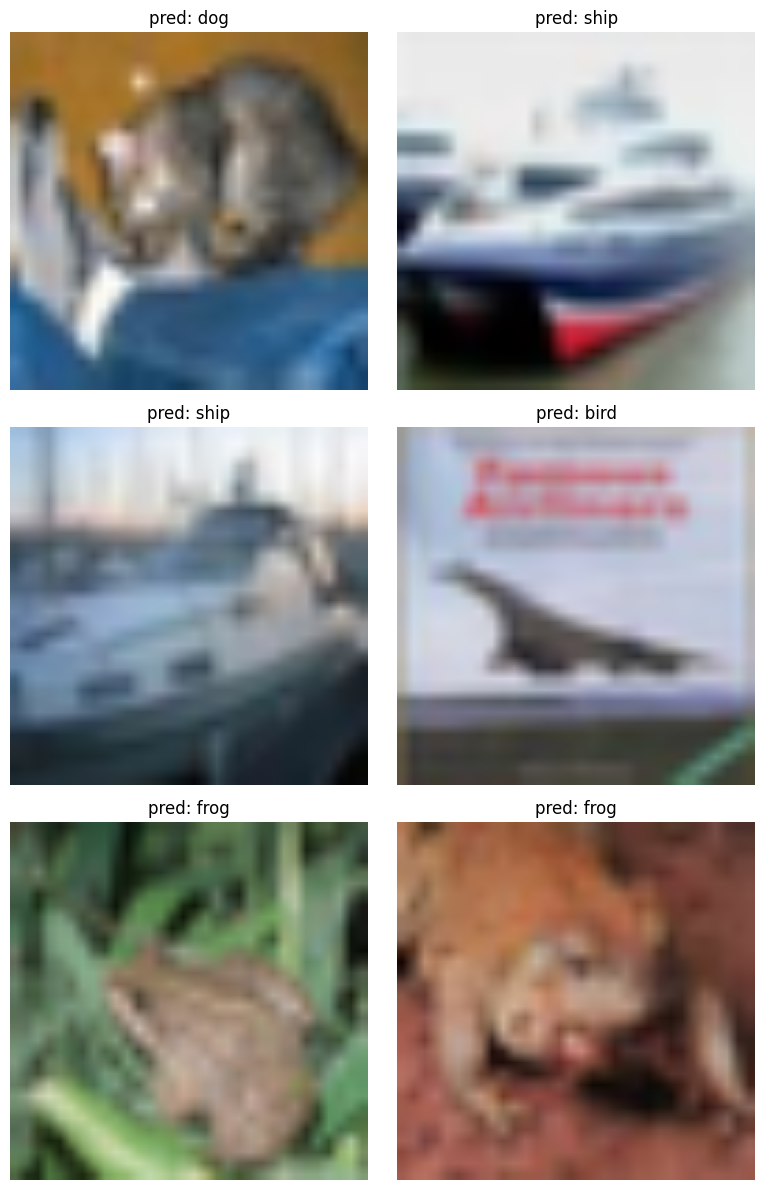

In [3]:
### Transfer Learning ###
criterion = nn.CrossEntropyLoss()

## Fixed Feature Extraction ##
model_ffe = models.efficientnet_b0(weights='IMAGENET1K_V1')
# Freeze backbone
for param in model_ffe.parameters():
    param.requires_grad = False
# Replace classifier head
num_ftrs = model_ffe.classifier[1].in_features
model_ffe.classifier[1] = nn.Linear(num_ftrs, len(class_names))
model_ffe = model_ffe.to(device)

# EfficientNet-B0 classifier has a dropout + fc layer
# The dropout has no learned weights so we can pass the whole classifier in
optimizer_ffe = optim.AdamW(model_ffe.classifier.parameters(), lr=1e-3)

model_ffe = train_model(model_ffe, criterion, optimizer_ffe, num_epochs=5)
torch.save(model_ffe.state_dict(), 'efficientnet_b0_ffe.pth')
print("Saved model to efficientnet_b0_ffe.pth")
visualize_model(model_ffe)

In [4]:
from google.colab import drive
drive.mount('/content/drive')
torch.save(model_ffe.state_dict(), '/content/drive/MyDrive/efficientnet_b0_ffe.pth')

Mounted at /content/drive


In [ ]:
## Fine-tuning
model_ft = models.efficientnet_b0(weights='IMAGENET1K_V1')
# Transfer classifier weights from FFE
model_ft.classifier[1] = nn.Linear(num_ftrs, len(class_names))
model_ft.classifier[1].load_state_dict(model_ffe.classifier[1].state_dict())
model_ft = model_ft.to(device)

optimizer_ft = optim.AdamW(model_ft.parameters(), lr=1e-4)
# Using Cosine Annealing because I don't want to tune step sizes and gammas
scheduler_ft = lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=20)

model_ft = train_model(model_ft, criterion, optimizer_ft, scheduler_ft, num_epochs=20)
torch.save(model_ft.state_dict(), 'efficientnet_b0_ft.pth')
torch.save(model_ffe.state_dict(), '/content/drive/MyDrive/efficientnet_b0_ffe.pth')
print("Saved model to efficientnet_b0_ft.pth")
visualize_model(model_ft)

Epoch 0/19
-------------------------
train Loss: 0.3428 Acc: 0.8827
val Loss: 0.1556 Acc: 0.9476

Epoch 1/19
-------------------------
train Loss: 0.1790 Acc: 0.9372
val Loss: 0.1186 Acc: 0.9594

Epoch 2/19
-------------------------
train Loss: 0.1252 Acc: 0.9568
val Loss: 0.1056 Acc: 0.9658

Epoch 3/19
-------------------------
train Loss: 0.0930 Acc: 0.9677
val Loss: 0.1050 Acc: 0.9656

Epoch 4/19
-------------------------
train Loss: 0.0709 Acc: 0.9754
val Loss: 0.1150 Acc: 0.9663

Epoch 5/19
-------------------------
train Loss: 0.0588 Acc: 0.9798
val Loss: 0.1049 Acc: 0.9684

Epoch 6/19
-------------------------
train Loss: 0.0466 Acc: 0.9837
val Loss: 0.1037 Acc: 0.9685

Epoch 7/19
-------------------------
train Loss: 0.0356 Acc: 0.9874
val Loss: 0.1168 Acc: 0.9681

Epoch 8/19
-------------------------
train Loss: 0.0323 Acc: 0.9891
val Loss: 0.1059 Acc: 0.9725

Epoch 9/19
-------------------------
train Loss: 0.0259 Acc: 0.9914
val Loss: 0.1107 Acc: 0.9693

Epoch 10/19
--------

In [ ]:
# Save before session dies
torch.save({
    'epoch': current_epoch,
    'model_state_dict': model_ft.state_dict(),
    'optimizer_state_dict': optimizer_ft.state_dict(),
    'scheduler_state_dict': scheduler_ft.state_dict(),
}, 'ft_checkpoint.pth')
